In [25]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from collections import Counter, defaultdict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import ttest_ind
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, make_scorer, accuracy_score, f1_score, r2_score, mean_absolute_error, mutual_info_score, roc_curve, zero_one_loss, davies_bouldin_score
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, normalize
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier


Text(0.5, 1.0, 'Weekly samples & defect ratio')

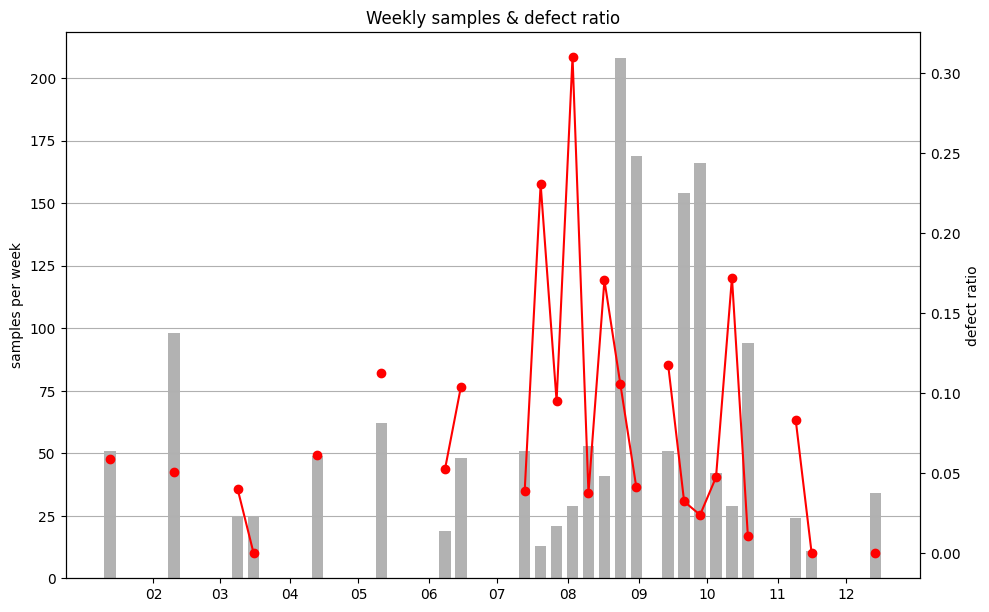

In [26]:
secom = pd.read_csv(data_path, sep='\t')
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

time_dt = pd.to_datetime(secom['Time'])
df = pd.DataFrame({'Time':time_dt, 'y':y}).sort_values('Time').set_index('Time')

w = df['y'].resample('W') # W means the end of the date
cnt, rate = w.size(), w.mean() # rate means 1/0 (fail/pass) less is better

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(cnt.index, cnt.values, width=5, alpha=0.3, color='k')
ax1.set_ylabel('samples per week')
ax1.grid(True, axis='y')

ax2 = ax1.twinx()
ax2.plot(rate.index, rate.values, marker='o', color='r')
ax2.set_ylabel('defect ratio')
months = pd.date_range(rate.index.min().normalize(),
                       rate.index.max().normalize(), freq='MS') 
ax2.set_xticks(months)
ax2.set_xticklabels([d.strftime('%m') for d in months], rotation=0, ha='center')

plt.tight_layout()
plt.title('Weekly samples & defect ratio')


PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


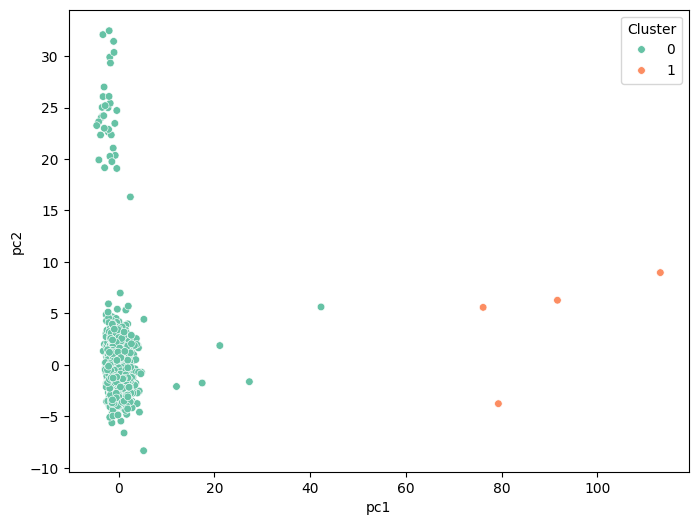

In [36]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

PCA 保留 133 個主成分
cluster sizes: {0: 32, 1: 1531}
cluster   0     1
y                
0        25  1435
1         7    96


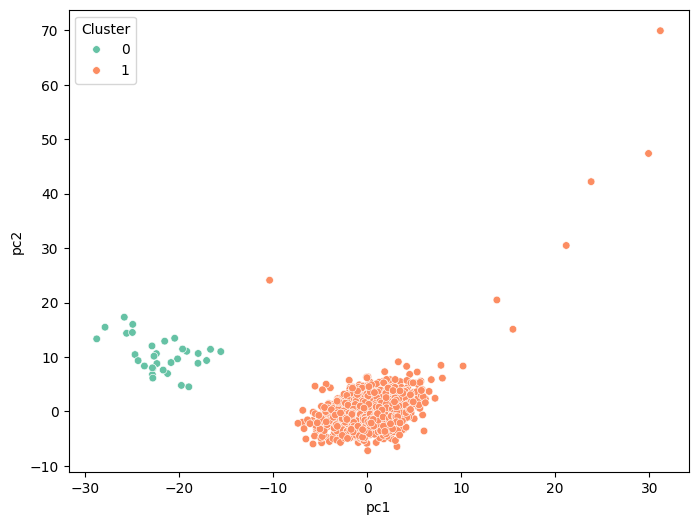

In [ ]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>50)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

In [77]:
X_pca_df['Cluster'] = X_pca_df['Cluster'].replace(3, 1)

In [18]:
X_pca_df['Cluster'].value_counts()

Cluster
0    641
2    538
1    346
Name: count, dtype: int64

In [19]:
mask = (labels == 0)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

smote = SMOTE(random_state=42, sampling_strategy=1)
Xtr, ytr = smote.fit_resample(Xtr, ytr)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))


LogisticRegression confusion matrix:
[[100  19]
 [  6   4]]

SVM(RBF) confusion matrix:
[[119   0]
 [ 10   0]]

DecisionTree confusion matrix:
[[99 20]
 [ 8  2]]

RandomForest confusion matrix:
[[118   1]
 [ 10   0]]

XGBoost confusion matrix:
[[115   4]
 [ 10   0]]

Summary metrics:
                        acc     FAR  sensitivity  specificity      GM
model                                                               
LogisticRegression  0.8062  0.1597          0.4       0.8403  0.5798
SVM(RBF)            0.9225  0.0000          0.0       1.0000  0.0000
DecisionTree        0.7829  0.1681          0.2       0.8319  0.4079
RandomForest        0.9147  0.0084          0.0       0.9916  0.0000
XGBoost             0.8915  0.0336          0.0       0.9664  0.0000


In [20]:
mask = (labels == 1)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=10)
Xtr, ytr = smote.fit_resample(Xtr, ytr)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))


LogisticRegression confusion matrix:
[[60  6]
 [ 4  0]]

SVM(RBF) confusion matrix:
[[66  0]
 [ 4  0]]

DecisionTree confusion matrix:
[[57  9]
 [ 3  1]]

RandomForest confusion matrix:
[[66  0]
 [ 4  0]]

XGBoost confusion matrix:
[[66  0]
 [ 3  1]]

Summary metrics:
                        acc     FAR  sensitivity  specificity      GM
model                                                               
LogisticRegression  0.8571  0.0909         0.00       0.9091  0.0000
SVM(RBF)            0.9429  0.0000         0.00       1.0000  0.0000
DecisionTree        0.8286  0.1364         0.25       0.8636  0.4647
RandomForest        0.9429  0.0000         0.00       1.0000  0.0000
XGBoost             0.9571  0.0000         0.25       1.0000  0.5000


In [21]:
mask = (labels == 2)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=10)
Xtr, ytr = smote.fit_resample(Xtr, ytr)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))


LogisticRegression confusion matrix:
[[100   3]
 [  4   1]]

SVM(RBF) confusion matrix:
[[103   0]
 [  5   0]]

DecisionTree confusion matrix:
[[89 14]
 [ 5  0]]

RandomForest confusion matrix:
[[103   0]
 [  5   0]]

XGBoost confusion matrix:
[[103   0]
 [  5   0]]

Summary metrics:
                        acc     FAR  sensitivity  specificity      GM
model                                                               
LogisticRegression  0.9352  0.0291          0.2       0.9709  0.4407
SVM(RBF)            0.9537  0.0000          0.0       1.0000  0.0000
DecisionTree        0.8241  0.1359          0.0       0.8641  0.0000
RandomForest        0.9537  0.0000          0.0       1.0000  0.0000
XGBoost             0.9537  0.0000          0.0       1.0000  0.0000


In [30]:
sil = silhouette_score(X_pca, labels)
dbi = davies_bouldin_score(X_pca, labels)

print(f"Silhouette score: {sil:.4f}")
print(f"Davies-Bouldin index: {dbi:.4f}")

Silhouette score: 0.3247
Davies-Bouldin index: 1.3418


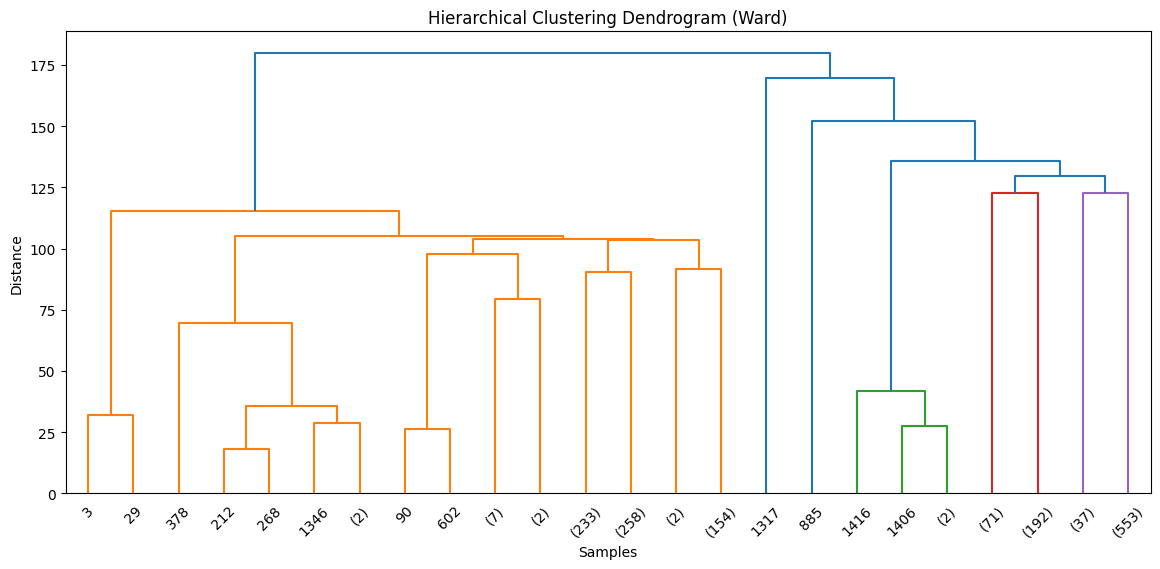

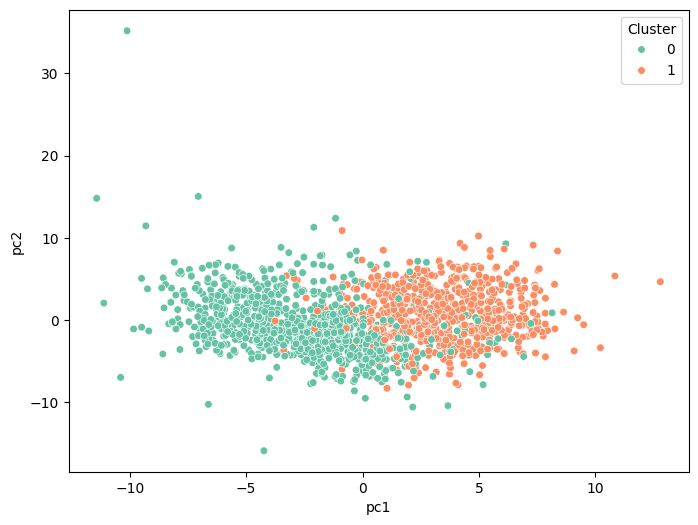

cluster    0    1
y                
0        822  608
1         37   58


In [37]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

# 用 Ward linkage 建 dendrogram（agglomerative 標準做法）
Z = linkage(X_pca, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='level', p=5)   # p=5 保留前幾層以免太大
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = agg.fit_predict(X_pca)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

In [39]:
mask = (labels == 1)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=10)
Xtr, ytr = smote.fit_resample(Xtr, ytr)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))


LogisticRegression confusion matrix:
[[106  16]
 [ 10   2]]

SVM(RBF) confusion matrix:
[[122   0]
 [ 11   1]]

DecisionTree confusion matrix:
[[101  21]
 [  9   3]]

RandomForest confusion matrix:
[[122   0]
 [ 12   0]]

XGBoost confusion matrix:
[[119   3]
 [ 11   1]]

Summary metrics:
                        acc     FAR  sensitivity  specificity      GM
model                                                               
LogisticRegression  0.8060  0.1311       0.1667       0.8689  0.3805
SVM(RBF)            0.9179  0.0000       0.0833       1.0000  0.2887
DecisionTree        0.7761  0.1721       0.2500       0.8279  0.4549
RandomForest        0.9104  0.0000       0.0000       1.0000  0.0000
XGBoost             0.8955  0.0246       0.0833       0.9754  0.2851
